# Validation Duck

## Paths & Co

In [1]:
new_kalman_run = False
animation = False

In [2]:
# paths jupyter utwente
path_tc = '/home/jovyan/data/98_paper2_kf_dtm/01_tides/output/'
path_validation = '/home/jovyan/data/98_paper2_kf_dtm/02_Duck_validation_data/'

path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/22_23_Duck_DEM/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/22_23_Duck_DEM/output/'
path_altimetry_output = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/output/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n36.6257_s35.7784_w-76.1201_e-75.3896.nc'
fn_ddtm = 'DeltaDTM_v1_0_N36W076.tif'

epsg = 4326 # WGS84
epsg_local = 32618

year_start = 1993
year_end = 2020 # included

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr

from scipy import stats

from shapely import LineString

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_visualisation

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [5]:
# Observational noise
sigma_l = 0.35

# Model noise
factor = 1
sigma_q = factor * sigma_l

# Standard deviation of the initial state
std_init = 3

print(f'Observational noise: {round(sigma_l,2)} m')
print(f'Model noise: {round(sigma_q,2)} m')
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.35 m
Model noise: 0.35 m
Standard deviation of the initial state: 3 m


In [6]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Observations

In [7]:
# Altimetry
fn = 'tp_plus_ales_epsg32618.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [8]:
# Tidal correction
fn = 'tides_duck.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [9]:
# Cassie shorelines
folders = ['1_1992-08-10_1995-02-24/',
          '2_1995-03-21_2001-03-12/',
          '3_2001-04-13_2009-03-18/',
          '4_2009-04-12_2018-02-07/',
          '5_2018-02-23_2025-03-06/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

292 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 90 points (min: 55, max: 215).


In [10]:
# number of shorelines per year
pd.DataFrame([_.year for _ in c_dates]).value_counts(sort=False)

0   
1992     3
1993    16
1994    15
1995    11
1996    12
1997     8
1998    11
1999    13
2000    12
2001     6
2002    11
2003     9
2004    12
2005    13
2006    13
2007    10
2008    14
2009     9
2010    14
2011    11
2013     9
2014    11
2015    10
2016     8
2017     5
2018    10
2019    15
2020     1
Name: count, dtype: int64

In [11]:
# Load outlier-corrected shorelines
c_shorelines_corr = pickle.load(open(path_output + 'c_shorelines_corr.pkl', 'rb'))
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

## Validation data

In [12]:
vali_gdf = gpd.read_file(path_output + 'duck_vali_gdf.geojson')

## Initial state

In [13]:
init = xr.open_dataset(path_output+'init_4326_resolution_50m.tif').squeeze()

med_sl = pickle.load(open(path_output + f'med_sl{epsg}.pkl', 'rb'))
poly_shorelines = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))
poly_target = pickle.load(open(path_output + f'poly_target{epsg}.pkl', 'rb'))
poly_target_red = pickle.load(open(path_output + f'poly_target_red_{epsg}.pkl', 'rb'))

## Generate RTS-DTM

In [14]:
# %%prun -s cumulative
fn = 'x_state_s.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]
    
    x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(year_start, year_end, init, std_init, rs_shoreline, seg_length, alt, tidal_corr,
                                                                                          epsg, T_is_identity, max_distance, w_id, max_noupdate, std_pseudobs,
                                                                                          sigma_l, sigma_q, eps_factor)
            
    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)
        
    kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state, x_state_s, updated_points)

    # Save kf output
    pickle.dump(x_state, open(f'{path_output}x_state.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s, open(f'{path_output}x_state_s.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")
    

Loaded files from /home/jovyan/data/98_paper2_kf_dtm/22_23_Duck_DEM/output/.


## Remove height difference between validation and new DTM
from different height reference systems

In [15]:
diff_kf = kf_interp.drop(columns=['geometry']) - vali_gdf.drop(columns=['geometry'])
diff_rts = rts_interp.drop(columns=['geometry']) - vali_gdf.drop(columns=['geometry'])
diff_kf_rts = pd.concat([diff_kf, diff_rts], axis=0)

print(f'Mean of all differences (KF-Jarkus and RTS-validation): {round(diff_kf_rts.mean().mean(), 2)}, median: {round(diff_kf_rts.median().median(), 2)}')
bias = diff_kf_rts.median().median()
vali_red = vali_gdf.copy()
vali_red.loc[:, vali_red.columns != 'geometry'] += bias

Mean of all differences (KF-Jarkus and RTS-validation): 1.07, median: 1.06


In [16]:
pickle.dump(bias, open(path_output+'bias.pkl', 'wb'))

## Statistics of elevation differences

In [17]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(vali_red.geometry.x, vali_red.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', vali_red.geometry.x, vali_red.geometry.y)

In [18]:
# Reduce to area inside the shoreline polygon
init_inside_sl = init_interp[init_interp.intersects(poly_sl_corr)]
vali_inside_sl = vali_red[vali_red.intersects(poly_sl_corr)]
kf_inside_sl = kf_interp[kf_interp.intersects(poly_sl_corr)]
rts_inside_sl = rts_interp[rts_interp.intersects(poly_sl_corr)]

### Initial state - validation

In [19]:
vali_temp_mean = vali_red.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - vali_temp_mean
print(f'Difference initial state - vali has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - vali has 2033 non-NaN values.


In [20]:
CD_statistics.print_stats(diff_init)

Mean error: -0.38 m
---De-bias with mean---
Mean error: -0.0 m
Mean absolute error: 1.21 m
Root mean square error: 1.67 m
Mean absolute deviation from mean: 1.21 m
Median absolute deviation from median: 0.8 m


In [21]:
year_list = [int(_) for _ in vali_inside_sl.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], vali_red, year_list, reduce_mean=True, static=True)

# Consider only points inside shoreline polygon
stats_gdf_init_in_sl, all_diffs_init_in_sl = CD_statistics.all_stats_per_year(init_inside_sl['init'], vali_inside_sl, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - validation

In [22]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, vali_red, year_list, reduce_mean=True, static=False)
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, vali_red, year_list, reduce_mean=True, static=False)

# Consider only points inside shoreline polygon
stats_gdf_rts_in_sl, all_diffs_rts_in_sl = CD_statistics.all_stats_per_year(rts_inside_sl, vali_inside_sl, year_list, reduce_mean=True, static=False)
stats_gdf_kf_in_sl, all_diffs_kf_in_sl = CD_statistics.all_stats_per_year(kf_inside_sl, vali_inside_sl, year_list, reduce_mean=True, static=False)

In [23]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

In [24]:
def plot_stats(ax, which_stat, title, legend=False, inside_sl=False):
    if inside_sl==False:
        ax.plot(stats_gdf_init.index.astype('int'), stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - validation')
        ax.plot(stats_gdf_kf.index.astype('int'), stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
        ax.plot(stats_gdf_rts.index.astype('int'), stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    elif inside_sl==True:
        ax.plot(stats_gdf_init_in_sl.index.astype('int'), stats_gdf_init_in_sl[which_stat], '.-', c=c_init, label='Initial state - validation')
        ax.plot(stats_gdf_kf_in_sl.index.astype('int'), stats_gdf_kf_in_sl[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
        ax.plot(stats_gdf_rts_in_sl.index.astype('int'), stats_gdf_rts_in_sl[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=25)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=23, y=1)
    # ax.ticklabel_format(useOffset=False, style='plain')

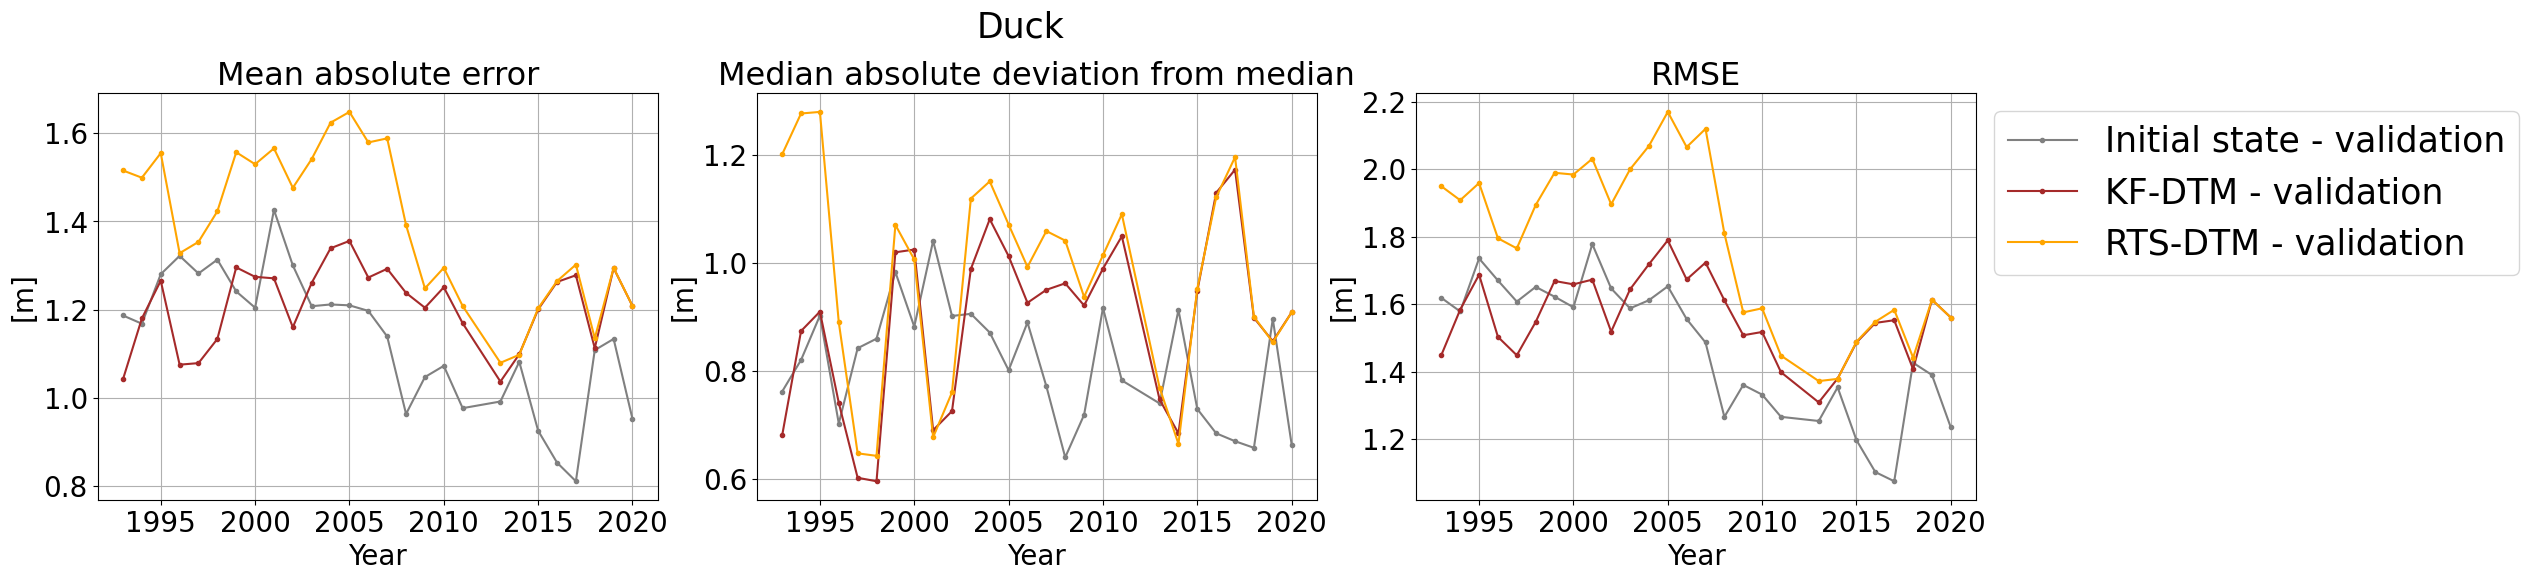

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle(f'Statistics of elevation differences averaged over the area covered by shoreline observations ({len(rts_inside_sl)} points)', y=1.1, fontsize=25)
fig.suptitle('Duck', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error', inside_sl=True)
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median', inside_sl=True)
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True, inside_sl=True)

plt.savefig(f'{path_output}Duck_vali_stats_elev-diffs_inside_shoreline_poly.png', dpi=300, bbox_inches='tight')

#### Quantify difference init - KF/RTS
positive: init has (on average) larger error  
negative: KF/RTS has larger error  

In [26]:
print(f'Average difference init-KF (inside shoreline area):')
print(f'ME: {round((stats_gdf_init_in_sl.mae - stats_gdf_kf_in_sl.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init_in_sl.mad_med - stats_gdf_kf_in_sl.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init_in_sl.rmse - stats_gdf_kf_in_sl.rmse).mean(),2)} m')

print(f'\nAverage difference init-RTS (inside shoreline area):')
print(f'ME: {round((stats_gdf_init_in_sl.mae - stats_gdf_rts_in_sl.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init_in_sl.mad_med - stats_gdf_rts_in_sl.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init_in_sl.rmse - stats_gdf_rts_in_sl.rmse).mean(),2)} m')

Average difference init-KF (inside shoreline area):
ME: -0.08 m
MAD: -0.08 m
RMSE: -0.09 m

Average difference init-RTS (inside shoreline area):
ME: -0.26 m
MAD: -0.16 m
RMSE: -0.31 m


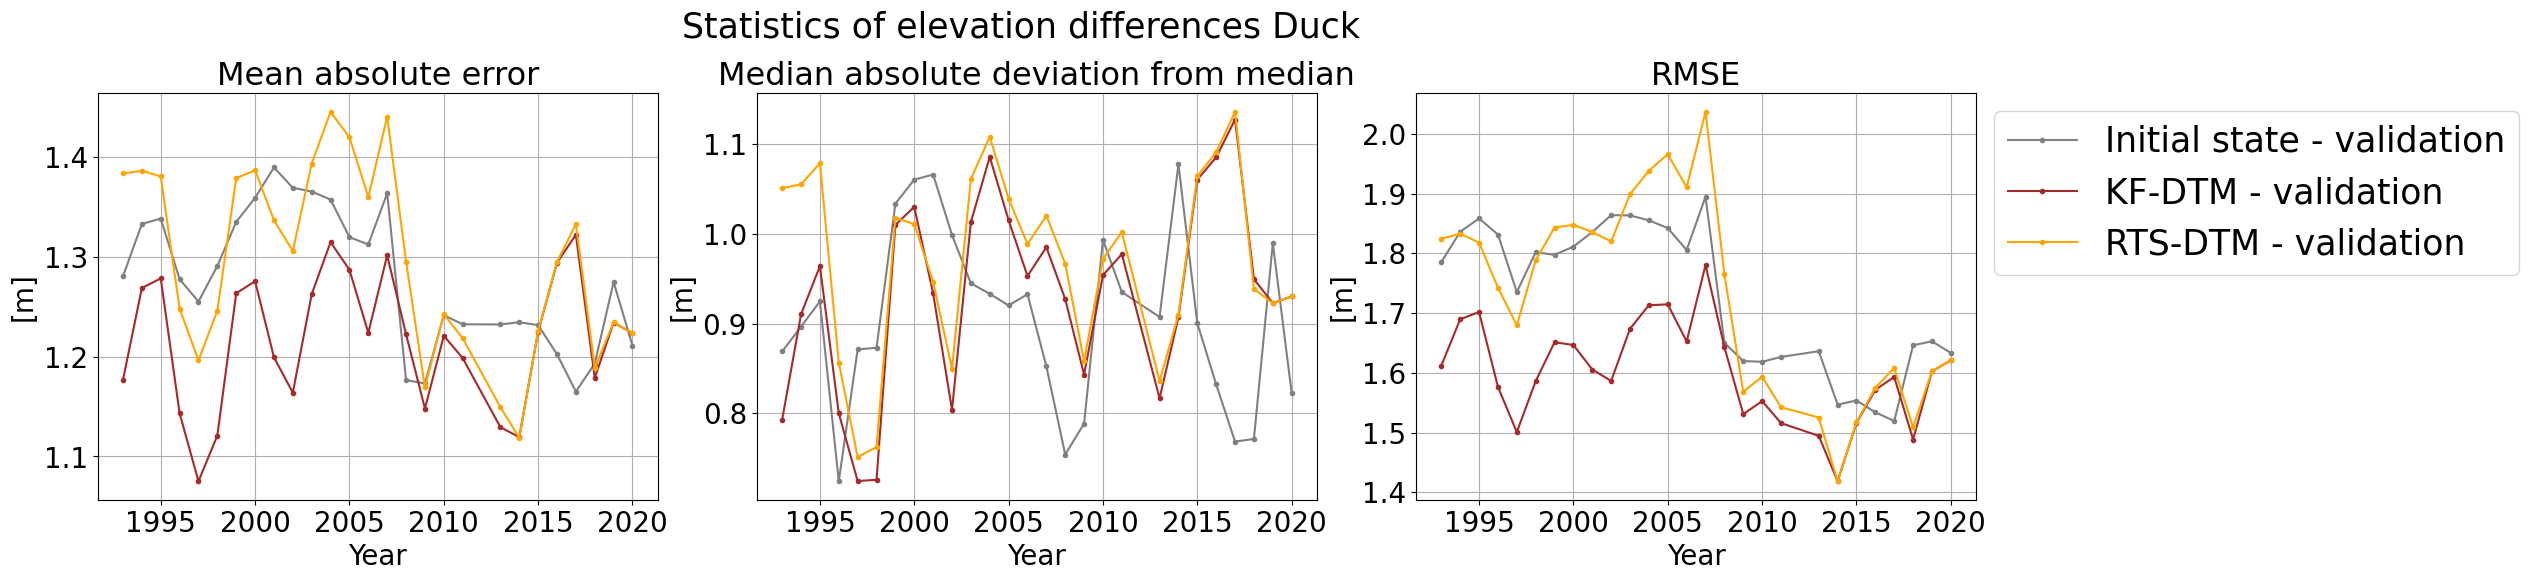

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle(f'Statistics of elevation differences averaged over the entire target area ({len(rts_interp)} points)', y=1.1, fontsize=25)
fig.suptitle(f'Statistics of elevation differences Duck', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error')
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True)

plt.savefig(f'{path_output}Duck_vali_stats_elev-diffs_entire_target_area.png', dpi=300, bbox_inches='tight')

### Maps

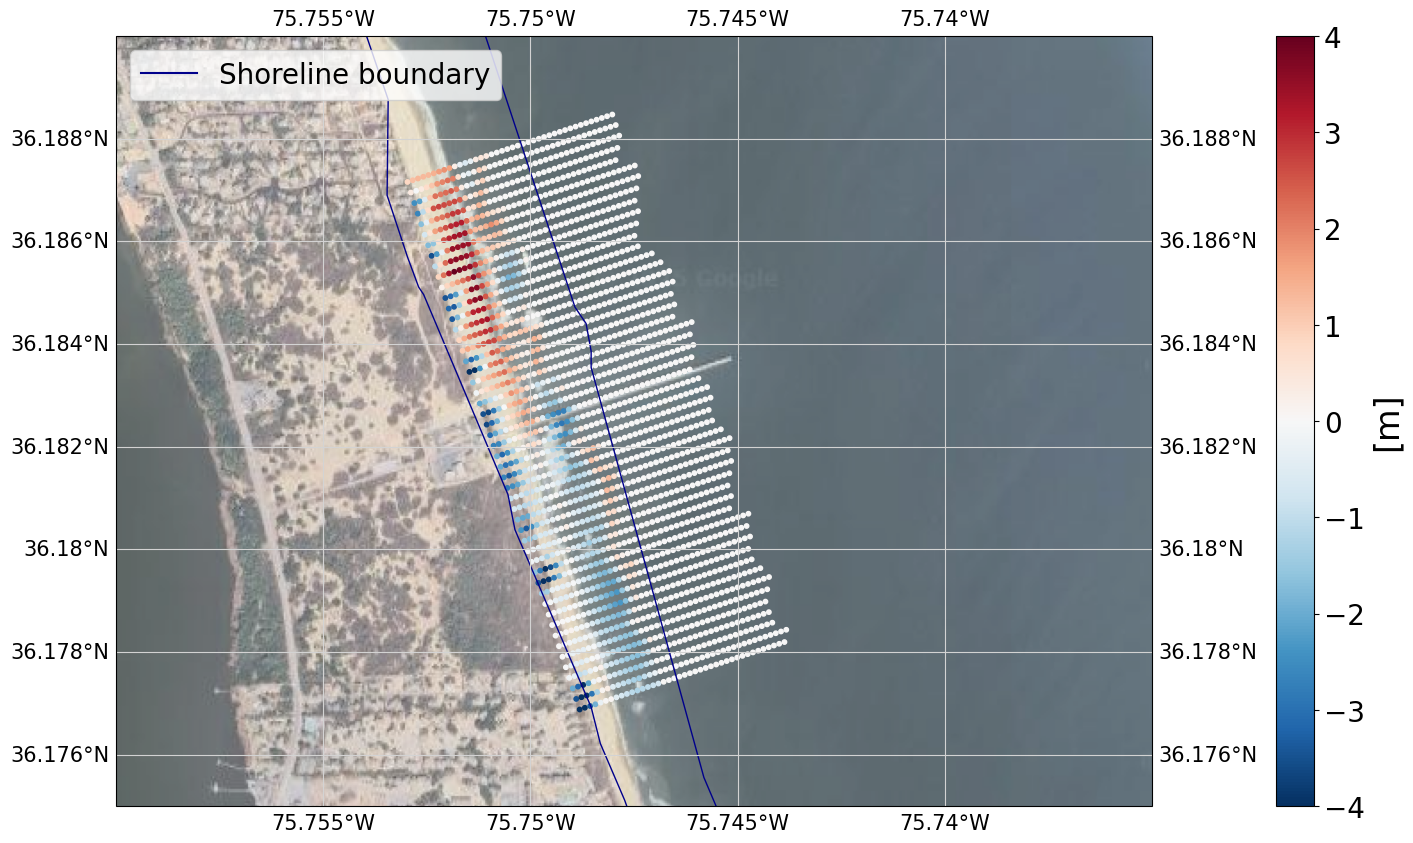

In [28]:
year = '1993'
diff_init = init_interp['init'] - vali_red[year]
diff_rts = rts_interp[year] - vali_red[year]
diff_rts_init = np.abs(diff_init) - np.abs(diff_rts)

extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

x = vali_red.geometry.x
y = vali_red.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff_rts_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

# ax.add_geometries(poly_target_red, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
# ax.set_title(f'Difference of errors initial state - RTS-DTM {year} for Duck', fontsize=24);

# plt.savefig(f'{path_output}Duck_map_diff_errors_init-RTS_{year}.png', dpi=300, bbox_inches='tight')

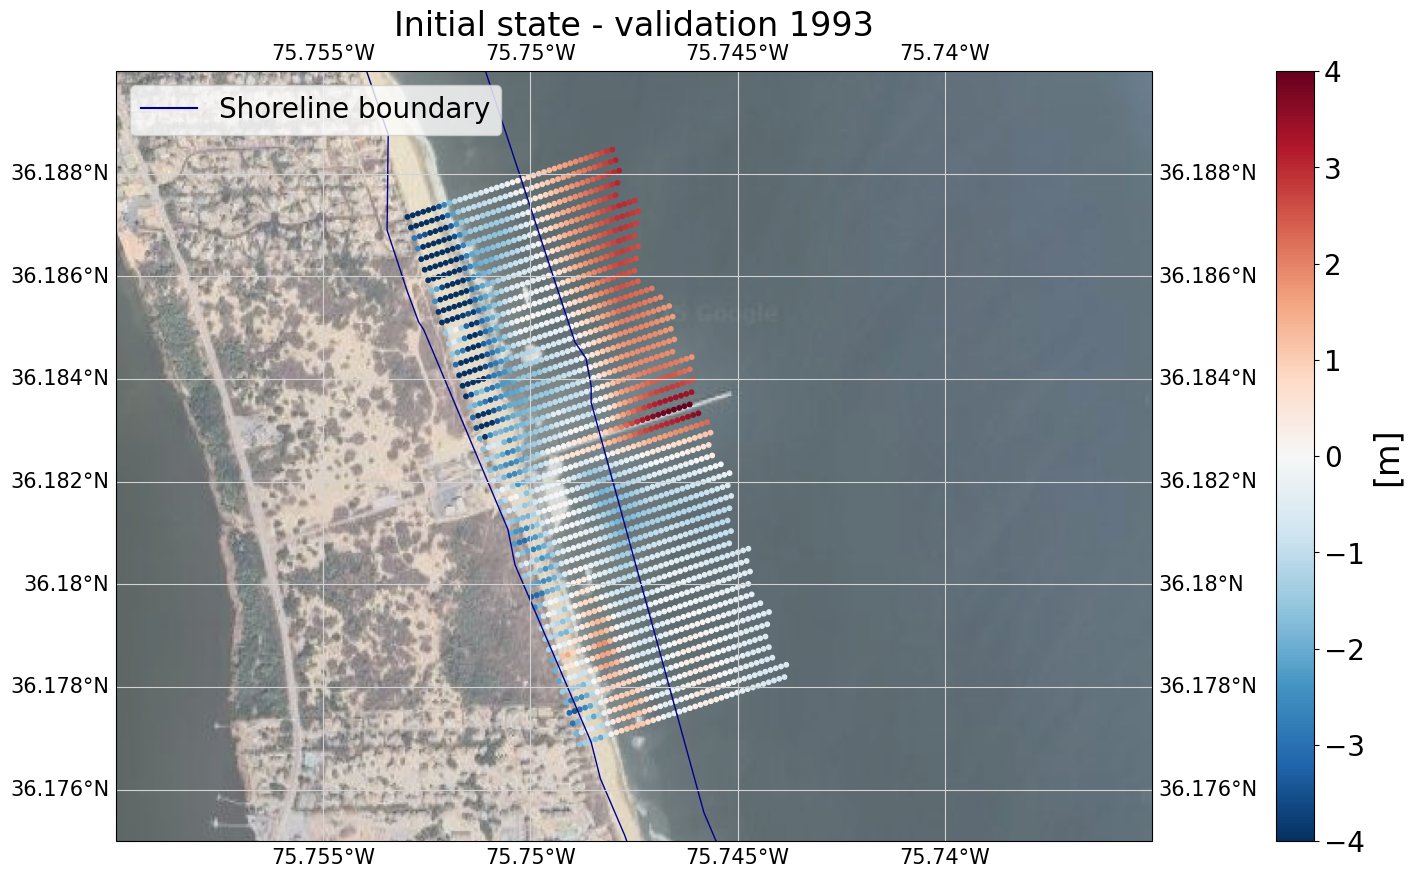

In [29]:
extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

x = vali_red.geometry.x
y = vali_red.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title(f'Initial state - validation 1993', fontsize=24);

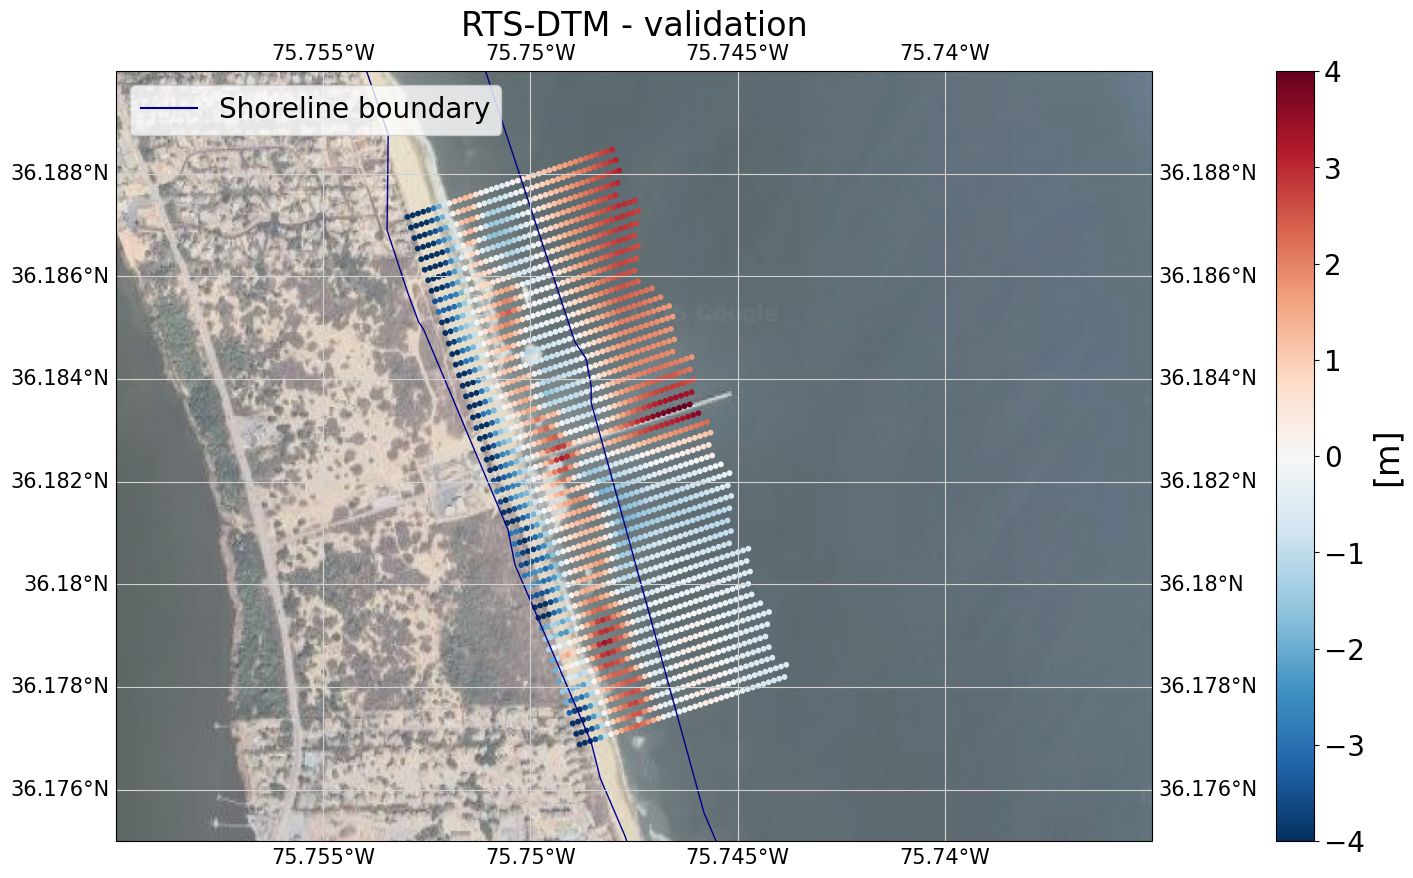

In [30]:
extent = [-75.76, -75.735, 36.175, 36.19]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

x = vali_red.geometry.x
y = vali_red.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff_rts, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-4, vmax=4)

ax.add_geometries(poly_sl_corr, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title(f'RTS-DTM - validation', fontsize=24);

## Time series of volume changes

In [31]:
volumes = pd.DataFrame(index=[int(_) for _ in vali_red.drop(columns='geometry').columns])

# Compute volumes over the reduced target area
volumes['vali'] = CD_geometry.compute_volume_changes(vali_red, poly_target_red, col_name='', epsg_out=epsg_local)
volumes['kf'] = CD_geometry.compute_volume_changes(kf_interp, poly_target_red, col_name='', epsg_out=epsg_local)
volumes['rts'] = CD_geometry.compute_volume_changes(rts_interp, poly_target_red, col_name='', epsg_out=epsg_local)

# # Compute volumes over the corrected shoreline area
# volumes['vali'] = CD_geometry.compute_volume_changes(vali_red, poly_sl_corr, col_name='', epsg_out=epsg_local)
# volumes['kf'] = CD_geometry.compute_volume_changes(kf_interp, poly_sl_corr, col_name='', epsg_out=epsg_local)
# volumes['rts'] = CD_geometry.compute_volume_changes(rts_interp, poly_sl_corr, col_name='', epsg_out=epsg_local)

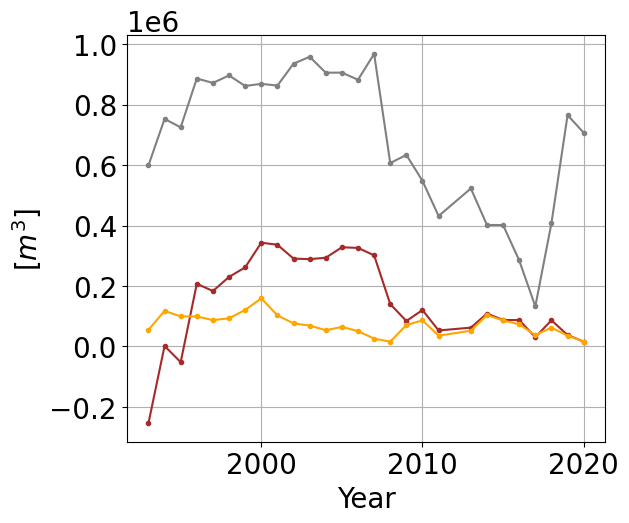

In [32]:
fig, ax = plt.subplots(figsize=(6,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.25)

ax.plot(volumes.index, volumes['vali'], '.-', c=c_init, label='Validation')
ax.plot(volumes.index, volumes['kf'], '.-', c=c_kf, label='KF-DTM')
ax.plot(volumes.index, volumes['rts'], '.-', c=c_rts, label='RTS-DTM')
ax.set_ylabel(r'[$m^3$]')
ax.set_xlabel('Year')
# ax.legend(bbox_to_anchor=(1,1), fontsize=22)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.grid()
# fig.suptitle('Volume changes Duck', fontsize=25, y=1.1)
plt.savefig(f'{path_output}Duck_validation_volume_changes.png', dpi=300, bbox_inches='tight')

### Statistics compared to the validation data set

In [33]:
rmse = CD_statistics.RMSE_timeseries(volumes['rts'], volumes['vali'])
print(f'rmse: {round(rmse,1)} m^3')

corr, p = stats.pearsonr(volumes['rts'], volumes['vali'])
print(f'corr: {round(corr,2)}, p: {round(p,2)}')

rmse: 223722.2 m^3
corr: 0.22, p: 0.28


In [34]:
rmse_perc = (np.abs(rmse)/np.abs(volumes['vali'].mean())) * 100
print('rmse in %:', round(rmse_perc,1))

rmse in %: 32.3


In [35]:
trends = {}
for col in volumes.columns:
    trends[col], _, _ = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int), volumes[col].values)
    
for key, value in trends.items():
    print(key, round(value,1), 'm^3/year')

vali -17349.6 m^3/year
kf -2657.7 m^3/year
rts -2211.0 m^3/year


In [36]:
trends

{'vali': -17349.6217, 'kf': -2657.6515, 'rts': -2210.9882}

In [37]:
diff = trends['rts'] - trends['vali']
t_diff_perc = (np.abs(diff) / np.abs(trends['vali'])) * 100
print('trend diff in %:', round(t_diff_perc,1))

trend diff in %: 87.3


## Animation

#### KF

In [38]:
if animation:
    extent = [-75.78, -75.73, 36.16, 36.2]
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x_state_in_sl_poly = x_state[x_state.intersects(poly_sl_corr)]
    
    x = x_state_in_sl_poly.geometry.x
    y = x_state_in_sl_poly.geometry.y
    anim = CD_visualisation.movie(x_state_in_sl_poly, x, y,
            col_list_kf, first_col='init', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='KF.gif')

#### RTS

In [39]:
if animation:
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    x_state_s_in_sl_poly = x_state_s[x_state_s.intersects(poly_sl_corr)]
    x = x_state_s_in_sl_poly.geometry.x
    y = x_state_s_in_sl_poly.geometry.y
    
    anim_RTS = CD_visualisation.movie(x_state_s_in_sl_poly, x, y,
                col_list_s, first_col='x_s_2020', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='RTS.gif')

#### Single year result map